# 📘 Session 2: Playing Style & Role Representations

## 🎯 Learning Objectives

By the end of this module, participants should be able to:

- Aggregate event + tracking data into possession-level features.

- Understand dimensionality reduction (PCA, t-SNE, UMAP) to create tactical embeddings.

- Perform clustering to identify team playing styles.

- Build player-level profiles (roles, heatmaps, embeddings).

- Link playing style analysis to defensive structure insights (Session 1).

In [2]:
import pandas as pd
import json
from pathlib import Path

BASE_DIR = Path("/Users/pegra441/Desktop/twelve-deep-learning/PremierLeague_data/2024")
DYNAMIC_DIR = BASE_DIR / "dynamic"
META_DIR = BASE_DIR / "meta"

records = []

# Loop through dynamic files
for fpath in DYNAMIC_DIR.glob("*.parquet"):
    match_id = int(fpath.stem)  # filename without extension

    # Try to load meta JSON for team names
    meta_path = META_DIR / f"{match_id}.json"
    if meta_path.exists():
        with open(meta_path, "r") as f:
            meta = json.load(f)
        home_team = meta["home_team"]["name"]
        away_team = meta["away_team"]["name"]
    else:
        home_team, away_team = None, None

    records.append({
        "id": match_id,
        "home_team": home_team,
        "away_team": away_team
    })

# Build DataFrame
df_matches = pd.DataFrame(records)

# Save as parquet
df_matches.to_parquet(BASE_DIR / "matches.parquet", index=False)

print("✅ matches.parquet created with shape:", df_matches.shape)
df_matches.head()


✅ matches.parquet created with shape: (378, 3)


,id,home_team,away_team
0,1986708,Crystal Palace,Brentford FC
1,1715920,Tottenham Hotspur,Arsenal Football Club
2,2015001,West Ham United,Tottenham Hotspur
3,1650385,Manchester United,Fulham
4,2007863,Leicester City,Manchester United


In [4]:
df_matches.shape

(378, 3)

In [2]:
import os, json
import pandas as pd
import numpy as np
from pathlib import Path

# --- Paths ---
BASE_DIR = Path("/Users/pegra441/Desktop/twelve-deep-learning/PremierLeague_data/2024")
DYNAMIC_DIR = BASE_DIR / "dynamic"
META_DIR = BASE_DIR / "meta"
TRACKING_DIR = BASE_DIR / "tracking"

# Pitch constants (SkillCorner → FIFA/mplsoccer scale)
X_MIN, X_MAX = -52, 52
Y_MIN, Y_MAX = -34, 34
PITCH_LENGTH, PITCH_WIDTH = 105, 68

# =====================================================
# Step 1. Build matches.parquet (if missing)
# =====================================================
matches_file = BASE_DIR / "matches.parquet"
if not matches_file.exists():
    records = []
    for fpath in DYNAMIC_DIR.glob("*.parquet"):
        match_id = int(fpath.stem)
        # Try to enrich with meta
        meta_path = META_DIR / f"{match_id}.json"
        if meta_path.exists():
            with open(meta_path, "r") as f:
                meta = json.load(f)
            home_team = meta["home_team"]["name"]
            away_team = meta["away_team"]["name"]
        else:
            home_team, away_team = None, None
        records.append({"id": match_id, "home_team": home_team, "away_team": away_team})
    df_matches = pd.DataFrame(records)
    df_matches.to_parquet(matches_file, index=False)
    print(f"✅ Built matches.parquet with {len(df_matches)} matches")
else:
    df_matches = pd.read_parquet(matches_file)
    print(f"✅ Loaded matches.parquet with {len(df_matches)} matches")

# =====================================================
# Step 2. Helper: rescale coords
# =====================================================
def rescale_to_pitch(df,
                     x_min=X_MIN, x_max=X_MAX,
                     y_min=Y_MIN, y_max=Y_MAX,
                     target_x=PITCH_LENGTH, target_y=PITCH_WIDTH):
    df = df.copy()
    df["x_rescaled"] = (df["x"] - x_min) / (x_max - x_min) * target_x
    df["y_rescaled"] = (df["y"] - y_min) / (y_max - y_min) * target_y
    if "x_end" in df.columns and "y_end" in df.columns:
        df["x_end_rescaled"] = (df["x_end"] - x_min) / (x_max - x_min) * target_x
        df["y_end_rescaled"] = (df["y_end"] - y_min) / (y_max - y_min) * target_y
    return df

# =====================================================
# Step 3. Helper: load meta mapping
# =====================================================
def load_meta_mapping(match_id: int):
    fpath = META_DIR / f"{match_id}.json"
    if not fpath.exists():
        return pd.DataFrame()

    with open(fpath, "r") as f:
        meta = json.load(f)

    home_team, away_team = meta["home_team"], meta["away_team"]
    records = []
    for p in meta.get("players", []):
        if "id" not in p:
            continue
        team_name = home_team["name"] if p["team_id"] == home_team["id"] else away_team["name"]
        team_shortname = home_team["short_name"] if p["team_id"] == home_team["id"] else away_team["short_name"]

        records.append({
            "match_id": meta["id"],
            "player_id_meta": p["id"],
            "player_short_name": p.get("short_name"),
            "player_team_id": p["team_id"],
            "player_team_name": team_name,
            "player_team_shortname": team_shortname,
            "player_position_group": p["player_role"]["position_group"] if p.get("player_role") else None,
            "player_role": p["player_role"]["name"] if p.get("player_role") else None
        })
    return pd.DataFrame(records)

# =====================================================
# Step 4. Build freeze frames for all matches
# =====================================================
all_freeze_frames = []

for match_id in df_matches["id"].values:
    # Load events
    try:
        df_events = pd.read_parquet(DYNAMIC_DIR / f"{match_id}.parquet")
    except:
        print(f"⚠️ No events for match {match_id}")
        continue

    # Only possession events
    df_events_pos = df_events[df_events["event_type"] == "player_possession"]

    # Event columns we care about
    df_events_end = df_events_pos[[
        "event_id","match_id","frame_start","frame_end",
        "time_start","time_end","team_id","attacking_side",
        "player_id","player_name","team_shortname",
        "start_type","end_type","x_start","y_start","x_end","y_end"
    ]]

    # Load tracking JSON
    fpath = TRACKING_DIR / f"{match_id}.json"
    if not fpath.exists():
        print(f"⚠️ No tracking for match {match_id}")
        continue
    with open(fpath, "r") as f:
        tracking_data = json.load(f)

    # Collect freeze frames
    frames = set(df_events_end["frame_start"].to_list() + df_events_end["frame_end"].to_list())
    custom_data = []
    for d in tracking_data:
        if d.get("frame") in frames and d.get("timestamp") is not None:
            for p in d["player_data"]:
                custom_data.append({
                    "match_id": match_id,
                    "time": d.get("timestamp"),
                    "frame": int(d.get("frame")),
                    "period": d.get("period"),
                    "player_id_tracking": p.get("player_id"),
                    "is_detected": p.get("is_detected"),
                    "is_ball": False,
                    "x": p.get("x"),
                    "y": p.get("y")
                })
            # Ball
            ball = d.get("ball_data")
            if ball and ball.get("is_detected") is not None:
                custom_data.append({
                    "match_id": match_id,
                    "time": d.get("timestamp"),
                    "frame": int(d.get("frame")),
                    "period": d.get("period"),
                    "player_id_tracking": -1,
                    "is_detected": ball.get("is_detected"),
                    "is_ball": True,
                    "x": ball.get("x"),
                    "y": ball.get("y")
                })

    df_frames = pd.DataFrame(custom_data)

    # Merge with events
    df_freeze = df_frames.merge(
        df_events_end,
        left_on=["match_id","frame"],
        right_on=["match_id","frame_end"],
        how="inner"
    ).rename(columns={"player_id": "player_id_event"})

    # Merge with meta
    df_meta = load_meta_mapping(match_id)
    if not df_meta.empty:
        df_freeze = df_freeze.merge(
            df_meta,
            left_on=["match_id","player_id_tracking"],
            right_on=["match_id","player_id_meta"],
            how="left"
        )

    # Rescale
    df_freeze = rescale_to_pitch(df_freeze)

    all_freeze_frames.append(df_freeze)

# =====================================================
# Step 5. Final dataset
# =====================================================
if all_freeze_frames:
    df_freeze_start_enriched = pd.concat(all_freeze_frames, ignore_index=True)
else:
    df_freeze_start_enriched = pd.DataFrame()

print("✅ Final freeze-frame shape:", df_freeze_start_enriched.shape)
df_freeze_start_enriched.head()


✅ Loaded matches.parquet with 378 matches
✅ Final freeze-frame shape: (8329949, 36)


,match_id,time,frame,period,player_id_tracking,is_detected,is_ball,x,y,event_id,...,player_short_name,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role,x_rescaled,y_rescaled,x_end_rescaled,y_end_rescaled
0,1986708,00:00:00.10,11,1,18526,False,False,-37.88,-0.79,8_0,...,D. Henderson,60.0,Crystal Palace,Crystal Palace,Other,Goalkeeper,14.255769,33.21,52.681731,34.21
1,1986708,00:00:00.10,11,1,12993,True,False,-16.39,-7.28,8_0,...,M. Lacroix,60.0,Crystal Palace,Crystal Palace,Central Defender,Center Back,35.952404,26.72,52.681731,34.21
2,1986708,00:00:00.10,11,1,25828,True,False,-7.98,-14.18,8_0,...,C. Richards,60.0,Crystal Palace,Crystal Palace,Central Defender,Right Center Back,44.443269,19.82,52.681731,34.21
3,1986708,00:00:00.10,11,1,23841,True,False,-12.22,5.27,8_0,...,M. Guéhi,60.0,Crystal Palace,Crystal Palace,Central Defender,Left Center Back,40.162500,39.27,52.681731,34.21
4,1986708,00:00:00.10,11,1,32267,True,False,-3.57,-24.64,8_0,...,D. Muñoz,60.0,Crystal Palace,Crystal Palace,Full Back,Right Wing Back,48.895673,9.36,52.681731,34.21


In [3]:
df_freeze_start_enriched.to_parquet('/Users/pegra441/Desktop/twelve-deep-learning/PremierLeague_data/Pl_freeze_frames.parquet')

In [4]:
df_freeze_start_enriched.columns

Index(['match_id', 'time', 'frame', 'period', 'player_id_tracking',
       'is_detected', 'is_ball', 'x', 'y', 'event_id', 'frame_start',
       'frame_end', 'time_start', 'time_end', 'team_id', 'attacking_side',
       'player_id_event', 'player_name', 'team_shortname', 'start_type',
       'end_type', 'x_start', 'y_start', 'x_end', 'y_end', 'player_id_meta',
       'player_short_name', 'player_team_id', 'player_team_name',
       'player_team_shortname', 'player_position_group', 'player_role',
       'x_rescaled', 'y_rescaled', 'x_end_rescaled', 'y_end_rescaled'],
      dtype='object')

In [5]:
df_freeze_start_enriched.team_shortname.value_counts()

team_shortname
Manchester City    551923
Liverpool          492817
Chelsea            483003
Manchester U       463979
Arsenal            463354
Fulham             448253
Tottenham          445795
Brighton           435846
Newcastle          423659
Southampton        420027
West Ham           415915
Aston Villa        403989
Wolverhampton      390134
Leicester          387762
Brentford FC       385502
Bournemouth        363189
Crystal Palace     359219
Everton            340576
Ipswich Town       336536
Nottingham         318471
Name: count, dtype: int64

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


In [7]:
# Load the dataset built in Session 1
df = df_freeze_start_enriched.copy()

print("Shape:", df.shape)
df.head()


Shape: (8329949, 36)


,match_id,time,frame,period,player_id_tracking,is_detected,is_ball,x,y,event_id,...,player_short_name,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role,x_rescaled,y_rescaled,x_end_rescaled,y_end_rescaled
0,1986708,00:00:00.10,11,1,18526,False,False,-37.88,-0.79,8_0,...,D. Henderson,60.0,Crystal Palace,Crystal Palace,Other,Goalkeeper,14.255769,33.21,52.681731,34.21
1,1986708,00:00:00.10,11,1,12993,True,False,-16.39,-7.28,8_0,...,M. Lacroix,60.0,Crystal Palace,Crystal Palace,Central Defender,Center Back,35.952404,26.72,52.681731,34.21
2,1986708,00:00:00.10,11,1,25828,True,False,-7.98,-14.18,8_0,...,C. Richards,60.0,Crystal Palace,Crystal Palace,Central Defender,Right Center Back,44.443269,19.82,52.681731,34.21
3,1986708,00:00:00.10,11,1,23841,True,False,-12.22,5.27,8_0,...,M. Guéhi,60.0,Crystal Palace,Crystal Palace,Central Defender,Left Center Back,40.162500,39.27,52.681731,34.21
4,1986708,00:00:00.10,11,1,32267,True,False,-3.57,-24.64,8_0,...,D. Muñoz,60.0,Crystal Palace,Crystal Palace,Full Back,Right Wing Back,48.895673,9.36,52.681731,34.21


In [8]:
# Group events by possession_id
# (if you don’t have possession_id, you can reconstruct from event sequence)
if "possession_id" in df.columns:
    df_possessions = df.groupby(["match_id", "possession_id"]).agg({
        "event_id": "count",
        "x_start": "first",
        "y_start": "first",
        "x_end": "last",
        "y_end": "last",
        "frame_start": "min",
        "frame_end": "max",
        "team_id": "first",
        "player_team_name": "first"
    }).reset_index()
else:
    print("⚠️ possession_id not found — use event grouping rules instead")


⚠️ possession_id not found — use event grouping rules instead


## ⚽️ Tutorial: Building Possessions from Events

We’ll work on the events table, not freeze-frames, because possession boundaries are event-based.

👉 The general rule you suggested:

A possession continues until the opponent team performs ≥2 consecutive actions.

That break → a new possession starts.


In [9]:
import pandas as pd
from pathlib import Path

DYNAMIC_DIR = Path("/Users/pegra441/Desktop/twelve-deep-learning/PremierLeague_data/2024/dynamic")

# Example: load all events into one big DataFrame
all_events = []
for f in DYNAMIC_DIR.glob("*.parquet"):
    df = pd.read_parquet(f)
    df["match_id"] = int(f.stem)
    all_events.append(df)

df_events_all = pd.concat(all_events, ignore_index=True)
print("All events:", df_events_all.shape)


All events: (1811078, 294)


In [10]:
# Step 2. Sort Events in Time
df_events_all = df_events_all.sort_values(
    ["match_id", "period", "frame_start"]
).reset_index(drop=True)


# Step 3. Construct Possession IDs
def assign_possessions(events_df):
    events_df = events_df.copy()
    possession_ids = []
    current_possession = 0
    last_team = None
    opponent_count = 0

    for idx, row in events_df.iterrows():
        team = row["team_id"]

        if last_team is None:
            # Start first possession
            current_possession += 1
            possession_ids.append(current_possession)
            last_team = team
            opponent_count = 0
            continue

        if team == last_team:
            # Same team continues possession
            possession_ids.append(current_possession)
            opponent_count = 0
        else:
            # Opponent action
            opponent_count += 1
            if opponent_count >= 2:
                # Switch possession
                current_possession += 1
                possession_ids.append(current_possession)
                last_team = team
                opponent_count = 0
            else:
                # Still count as previous possession
                possession_ids.append(current_possession)

    events_df["possession_id"] = possession_ids
    return events_df

df_events_all = df_events_all.groupby("match_id", group_keys=False).apply(assign_possessions)


/var/folders/3f/yft_5njd2yg67wbblcdlff800000gn/T/ipykernel_93121/3007072774.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_events_all = df_events_all.groupby("match_id", group_keys=False).apply(assign_possessions)


In [12]:
df_events_all[["match_id","period","frame_start","team_id","team_shortname","event_type","possession_id"]].head(30)


,match_id,period,frame_start,team_id,team_shortname,event_type,possession_id
0,1650385,1,52,48,Fulham,player_possession,1
1,1650385,1,59,48,Fulham,off_ball_run,1
2,1650385,1,62,48,Fulham,player_possession,1
3,1650385,1,62,48,Fulham,passing_option,1
4,1650385,1,62,31,Manchester U,on_ball_engagement,1
5,1650385,1,66,48,Fulham,passing_option,1
6,1650385,1,69,48,Fulham,passing_option,1
7,1650385,1,71,48,Fulham,passing_option,1
8,1650385,1,87,48,Fulham,player_possession,1
9,1650385,1,87,48,Fulham,passing_option,1


In [13]:
df_freeze_start_enriched = df_freeze_start_enriched.merge(
    df_events_all[["match_id","event_id","possession_id"]],
    on=["match_id","event_id"], how="left"
)



# 📘 Tutorial Notebook: Playing Style & Role Representations

In [27]:
# 0. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

In [28]:
# 1. Load Freeze-Frame Data with Possession IDs
# Suppose df_freeze_start_enriched is already built from Session 1
# and now includes a possession_id column.
df = df_freeze_start_enriched.copy()

print("Shape:", df.shape)
df.head()

Shape: (8329949, 37)


,match_id,time,frame,period,player_id_tracking,is_detected,is_ball,x,y,event_id,...,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role,x_rescaled,y_rescaled,x_end_rescaled,y_end_rescaled,possession_id
0,1986708,00:00:00.10,11,1,18526,False,False,-37.88,-0.79,8_0,...,60.0,Crystal Palace,Crystal Palace,Other,Goalkeeper,14.255769,33.21,52.681731,34.21,1
1,1986708,00:00:00.10,11,1,12993,True,False,-16.39,-7.28,8_0,...,60.0,Crystal Palace,Crystal Palace,Central Defender,Center Back,35.952404,26.72,52.681731,34.21,1
2,1986708,00:00:00.10,11,1,25828,True,False,-7.98,-14.18,8_0,...,60.0,Crystal Palace,Crystal Palace,Central Defender,Right Center Back,44.443269,19.82,52.681731,34.21,1
3,1986708,00:00:00.10,11,1,23841,True,False,-12.22,5.27,8_0,...,60.0,Crystal Palace,Crystal Palace,Central Defender,Left Center Back,40.162500,39.27,52.681731,34.21,1
4,1986708,00:00:00.10,11,1,32267,True,False,-3.57,-24.64,8_0,...,60.0,Crystal Palace,Crystal Palace,Full Back,Right Wing Back,48.895673,9.36,52.681731,34.21,1


In [29]:
#2. Build Possession-Level Table

#Each possession = sequence of events until ball lost (we already computed possession_id).
#Now we aggregate possession features.

# Aggregate to possession level
df_possessions = (
    df.groupby(["match_id","possession_id","player_team_name"])
    .agg({
        "frame_start": "min",
        "frame_end": "max",
        "time_start": "min",
        "time_end": "max",
        "x_start": "first",
        "y_start": "first",
        "x_end": "last",
        "y_end": "last",
        "event_id": "count"  # number of events in possession
    })
    .reset_index()
)

# Basic possession features
df_possessions["duration_frames"] = df_possessions["frame_end"] - df_possessions["frame_start"]
df_possessions["net_progress_x"] = df_possessions["x_end"] - df_possessions["x_start"]
df_possessions["net_progress_y"] = df_possessions["y_end"] - df_possessions["y_start"]
df_possessions["progress_distance"] = np.sqrt(
    df_possessions["net_progress_x"]**2 + df_possessions["net_progress_y"]**2
)

print("Possessions:", df_possessions.shape)
df_possessions.head()

Possessions: (231146, 16)


,match_id,possession_id,player_team_name,frame_start,frame_end,time_start,time_end,x_start,y_start,x_end,y_end,event_id,duration_frames,net_progress_x,net_progress_y,progress_distance
0,1650385,1,Fulham,52,182,00:04.2,00:17.2,0.37,-0.51,-13.67,32.22,55,130,-14.04,32.73,35.614246
1,1650385,1,Manchester United,52,182,00:04.2,00:17.2,0.37,-0.51,-13.67,32.22,55,130,-14.04,32.73,35.614246
2,1650385,3,Fulham,189,196,00:17.9,00:18.6,-5.78,33.63,-3.84,34.11,11,7,1.94,0.48,1.998499
3,1650385,3,Manchester United,189,196,00:17.9,00:18.6,-5.78,33.63,-3.84,34.11,11,7,1.94,0.48,1.998499
4,1650385,4,Fulham,222,968,00:21.2,01:35.8,-9.24,18.66,2.38,32.24,121,746,11.62,13.58,17.872907


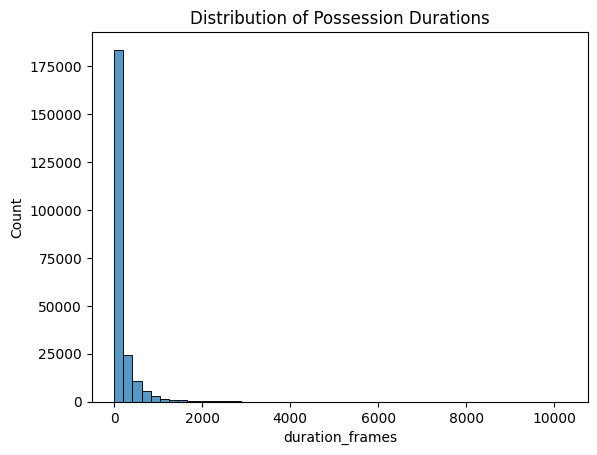

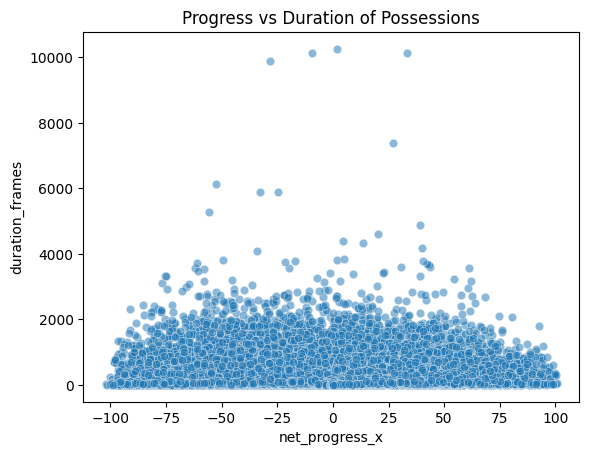

In [30]:
#3. Explore Possession Features
sns.histplot(df_possessions["duration_frames"], bins=50)
plt.title("Distribution of Possession Durations")
plt.show()

sns.scatterplot(data=df_possessions, x="net_progress_x", y="duration_frames", alpha=0.3)
plt.title("Progress vs Duration of Possessions")
plt.show()

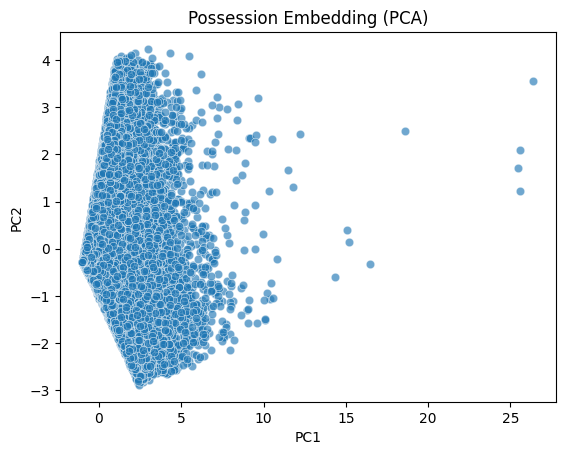

In [31]:
# 4. Dimensionality Reduction (PCA)
features = ["duration_frames","progress_distance","net_progress_x"]
X = df_possessions[features].fillna(0)

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_possessions["PC1"] = X_pca[:,0]
df_possessions["PC2"] = X_pca[:,1]

sns.scatterplot(data=df_possessions, x="PC1", y="PC2", alpha=0.4)
plt.title("Possession Embedding (PCA)")
plt.show()

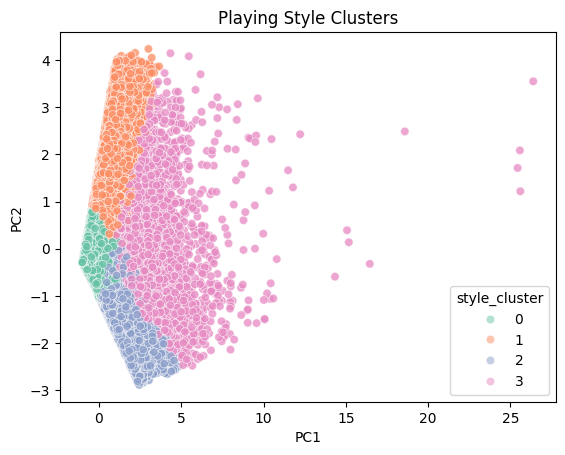

In [32]:
# 5. Cluster Playing Styles
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
df_possessions["style_cluster"] = kmeans.fit_predict(X_scaled)

sns.scatterplot(data=df_possessions, x="PC1", y="PC2", hue="style_cluster", palette="Set2", alpha=0.5)
plt.title("Playing Style Clusters")
plt.show()

## 👉 At this point, we see distinct possession clusters.

- Cluster 0 → Direct transitions

- Cluster 1 → Tiki-taka buildup

- Cluster 2 → High press recoveries

- Cluster 3 → Chaotic turnovers

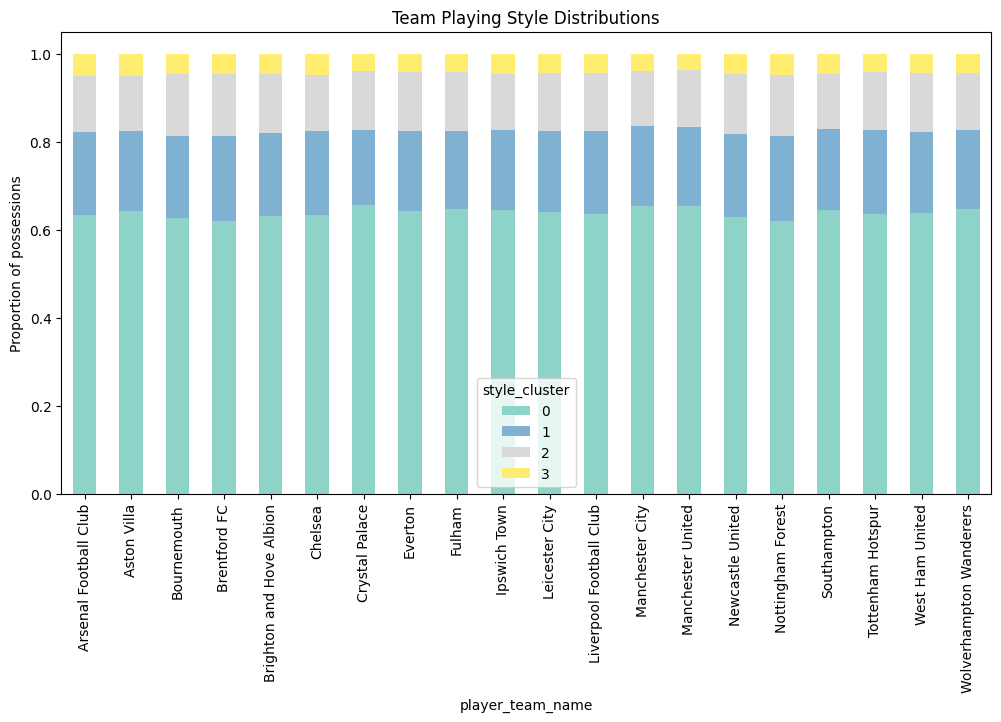

In [33]:
# 6. Team-Level Style Fingerprints
team_styles = (
    df_possessions.groupby("player_team_name")["style_cluster"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

team_styles.plot(kind="bar", stacked=True, figsize=(12,6), colormap="Set3")
plt.title("Team Playing Style Distributions")
plt.ylabel("Proportion of possessions")
plt.show()

## 👉 Compare how Arsenal vs Newcastle vs Man City differ in style mix.

In [35]:
df_possessions

,match_id,possession_id,player_team_name,frame_start,frame_end,time_start,time_end,x_start,y_start,x_end,y_end,event_id,duration_frames,net_progress_x,net_progress_y,progress_distance,PC1,PC2,style_cluster
0,1650385,1,Fulham,52,182,00:04.2,00:17.2,0.37,-0.51,-13.67,32.22,55,130,-14.04,32.73,35.614246,0.375903,-0.435017,0
1,1650385,1,Manchester United,52,182,00:04.2,00:17.2,0.37,-0.51,-13.67,32.22,55,130,-14.04,32.73,35.614246,0.375903,-0.435017,0
2,1650385,3,Fulham,189,196,00:17.9,00:18.6,-5.78,33.63,-3.84,34.11,11,7,1.94,0.48,1.998499,-0.954003,-0.202699,0
3,1650385,3,Manchester United,189,196,00:17.9,00:18.6,-5.78,33.63,-3.84,34.11,11,7,1.94,0.48,1.998499,-0.954003,-0.202699,0
4,1650385,4,Fulham,222,968,00:21.2,01:35.8,-9.24,18.66,2.38,32.24,121,746,11.62,13.58,17.872907,1.294684,0.421718,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231141,2018580,383,Wolverhampton Wanderers,57042,57073,93:30.2,93:33.3,-47.64,0.51,-42.01,-3.85,11,31,5.63,-4.36,7.120850,-0.780019,-0.027383,0
231142,2018580,384,Brentford FC,57090,57115,93:35.0,93:37.5,25.80,18.03,32.97,24.20,11,25,7.17,6.17,9.459271,-0.742906,0.044103,0
231143,2018580,384,Wolverhampton Wanderers,57090,57115,93:35.0,93:37.5,25.80,18.03,32.97,24.20,11,25,7.17,6.17,9.459271,-0.742906,0.044103,0
231144,2018580,385,Brentford FC,57536,57540,94:19.6,94:20.0,48.52,-7.48,-50.05,1.47,22,4,-98.57,8.95,98.975489,2.342612,-2.810831,2


Guarantee Player-Level Info in df_possessions
Step 1. When aggregating possessions, include player info

Instead of only aggregating numeric features, also grab the player columns (player_id_event, player_name, team_shortname).

In [37]:
# Aggregate possessions with possessor info
df_possessions = (
    df.groupby(["match_id","possession_id"])
    .agg({
        "frame_start": "min",
        "frame_end": "max",
        "time_start": "min",
        "time_end": "max",
        "x_start": "first",
        "y_start": "first",
        "x_end": "last",
        "y_end": "last",
        "event_id": "count",
        # possessor info (take first event of possession)
        "player_id_event": "first",
        "player_name": "first",
        "team_shortname": "first",
        "player_team_name": "first"
    })
    .reset_index()
)

# Features
df_possessions["duration_frames"] = df_possessions["frame_end"] - df_possessions["frame_start"]
df_possessions["net_progress_x"] = df_possessions["x_end"] - df_possessions["x_start"]
df_possessions["net_progress_y"] = df_possessions["y_end"] - df_possessions["y_start"]
df_possessions["progress_distance"] = np.sqrt(
    df_possessions["net_progress_x"]**2 + df_possessions["net_progress_y"]**2
)

print("Possessions:", df_possessions.shape)
df_possessions.head()



Possessions: (115573, 19)


,match_id,possession_id,frame_start,frame_end,time_start,time_end,x_start,y_start,x_end,y_end,event_id,player_id_event,player_name,team_shortname,player_team_name,duration_frames,net_progress_x,net_progress_y,progress_distance
0,1650385,1,52,182,00:04.2,00:17.2,0.37,-0.51,-13.67,32.22,115,11438,Andreas Pereira,Fulham,Manchester United,130,-14.04,32.73,35.614246
1,1650385,3,189,196,00:17.9,00:18.6,-5.78,33.63,-3.84,34.11,23,6847,M. Rashford,Manchester U,Manchester United,7,1.94,0.48,1.998499
2,1650385,4,222,968,00:21.2,01:35.8,-9.24,18.66,2.38,32.24,253,1674,Casemiro,Manchester U,Manchester United,746,11.62,13.58,17.872907
3,1650385,5,981,981,01:37.1,01:37.1,0.87,24.34,0.87,24.34,23,70672,K. Mainoo,Manchester U,Manchester United,0,0.00,0.00,0.000000
4,1650385,6,991,1692,01:38.1,02:48.2,-2.87,31.57,19.05,-9.08,414,6847,M. Rashford,Manchester U,Manchester United,701,21.92,-40.65,46.183427


In [38]:
#Step 2. Player Role Embeddings

#We can now group by player_name safely:

# Features to describe playing style
features = ["duration_frames", "progress_distance", "net_progress_x"]

player_roles = (
    df_possessions.groupby("player_name")[features]
    .mean()
    .fillna(0)
)

print("Player embeddings:", player_roles.shape)
player_roles.head()

Player embeddings: (548, 3)


,duration_frames,progress_distance,net_progress_x
player_name,,,
A. Agbinone,92.400000,20.258649,-6.698000
A. Armstrong,118.652174,18.687584,-1.630696
A. Aréola,194.298507,32.826605,25.434080
A. Bayındır,184.741935,43.428301,38.129032
A. Bella-Kotchap,159.467742,27.447237,8.634677


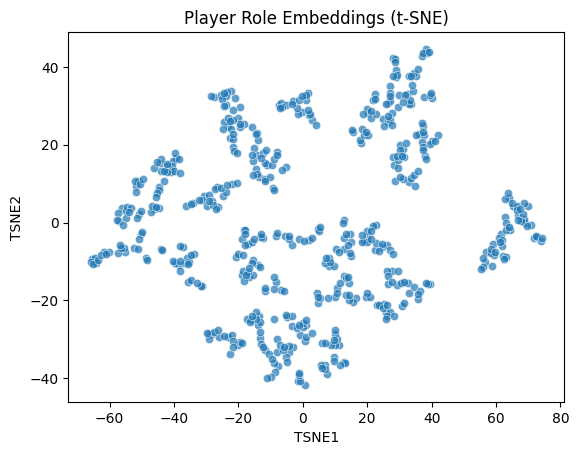

In [39]:
# Step 3. Proceed with Role Embedding & Similarity

# Now you can continue with PCA, t-SNE, cosine similarity, etc., exactly as in the tutorial:

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

# Scale
X_scaled = StandardScaler().fit_transform(player_roles)

# t-SNE for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
X_tsne = tsne.fit_transform(X_scaled)

player_roles["TSNE1"] = X_tsne[:,0]
player_roles["TSNE2"] = X_tsne[:,1]

sns.scatterplot(data=player_roles, x="TSNE1", y="TSNE2", alpha=0.7)
plt.title("Player Role Embeddings (t-SNE)")
plt.show()

👉 Each dot = player → clusters of similar roles.

In [40]:
# And the similarity search stays the same:

sim_matrix = cosine_similarity(X_scaled)
sim_df = pd.DataFrame(sim_matrix, index=player_roles.index, columns=player_roles.index)

def find_similar_players(player_name, top_n=5):
    if player_name not in sim_df.index:
        print(f"⚠️ {player_name} not found")
        return
    return sim_df[player_name].sort_values(ascending=False).iloc[1:top_n+1]

In [43]:
# 9. Similarity Search (Scouting Example)
sim_matrix = cosine_similarity(X_scaled)
sim_df = pd.DataFrame(sim_matrix, index=player_roles.index, columns=player_roles.index)

def find_similar_players(player_name, top_n=5):
    if player_name not in sim_df.index:
        print(f"⚠️ {player_name} not found")
        return
    sims = sim_df[player_name].sort_values(ascending=False).iloc[1:top_n+1]
    return sims

In [ ]:
# 10. Example: Find Similar Players to Rodri
similar_to_rodri = find_similar_players("Rodri", top_n=5)
print("Most similar players to Rodri:")
print(similar_to_rodri)


Most similar players to Rodri:
player_name
M. Harness     0.996872
D. Scarlett    0.994411
J. Monga       0.990974
Y. Konak       0.987590
C. Obi         0.984706
Name: Rodri, dtype: float64


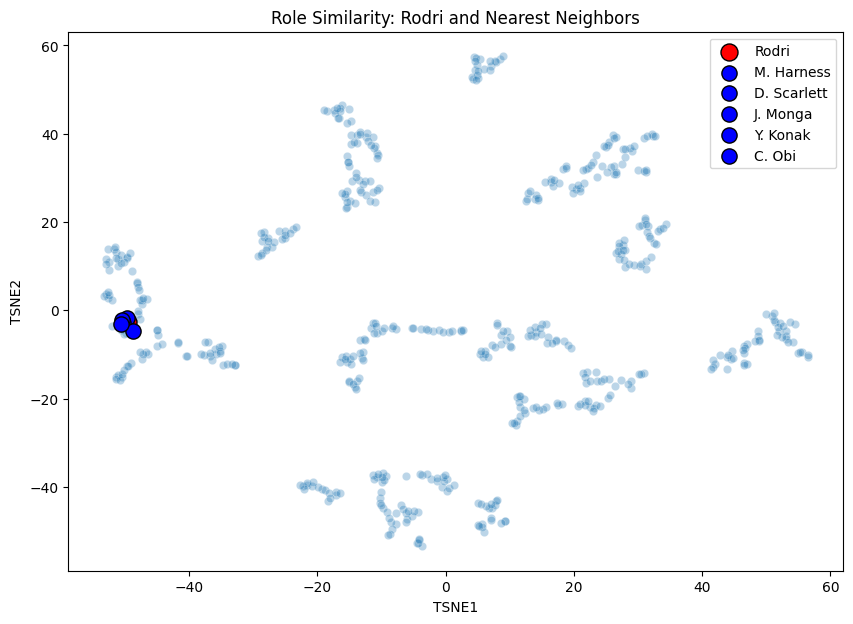

In [45]:
# 11. Visualization of Player + Neighbors
target = "Rodri"
neighbors = list(similar_to_rodri.index)

plt.figure(figsize=(10,7))
sns.scatterplot(data=player_roles, x="TSNE1", y="TSNE2", alpha=0.3)

# Highlight target
plt.scatter(player_roles.loc[target,"TSNE1"], player_roles.loc[target,"TSNE2"],
            color="red", s=150, edgecolors="k", label=target)

# Highlight neighbors
for n in neighbors:
    plt.scatter(player_roles.loc[n,"TSNE1"], player_roles.loc[n,"TSNE2"],
                color="blue", s=120, edgecolors="k", label=n)

plt.title(f"Role Similarity: {target} and Nearest Neighbors")
plt.legend()
plt.show()


12. Wrap-Up

Possessions → Playing Styles → Team Style Mix → Player Roles.

Similarity search = data-driven scouting.

Next steps:

Define role archetypes (playmaker, destroyer, winger, striker).

Track role changes across matches/seasons.

Compare opponent-specific adjustments.

# 🔥 Extension: Role Archetype Clustering

In [46]:
# 13. Clustering Players into Role Archetypes

# We use the same player_roles table (averaged possession features per player).

from sklearn.cluster import KMeans

# Features only (exclude TSNE coords)
role_features = ["duration_frames", "progress_distance", "net_progress_x"]

X_scaled = StandardScaler().fit_transform(player_roles[role_features])

# KMeans clustering
kmeans_roles = KMeans(n_clusters=6, random_state=42, n_init="auto")
player_roles["role_cluster"] = kmeans_roles.fit_predict(X_scaled)

In [47]:
# 14. Inspect Role Archetypes
role_summary = player_roles.groupby("role_cluster")[role_features].mean().round(2)
print(role_summary)

              duration_frames  progress_distance  net_progress_x
role_cluster                                                    
0                      120.76              21.72           -2.73
1                      279.47              55.65          -50.50
2                      212.99              37.01           28.56
3                       39.18               9.97            0.49
4                      461.49              39.61            9.33
5                      162.68              27.10            3.51


## 👉 Each row = archetype.
Example interpretations (to discuss with participants):

Cluster 0 → short-duration, big forward progress → “Direct transition players”

Cluster 1 → long-duration, small progress → “Tiki-taka playmakers”

Cluster 2 → very high progress_x → “Target strikers / long-ball outlets”

Cluster 3 → short duration, defensive recoveries → “Destroyers”

etc.

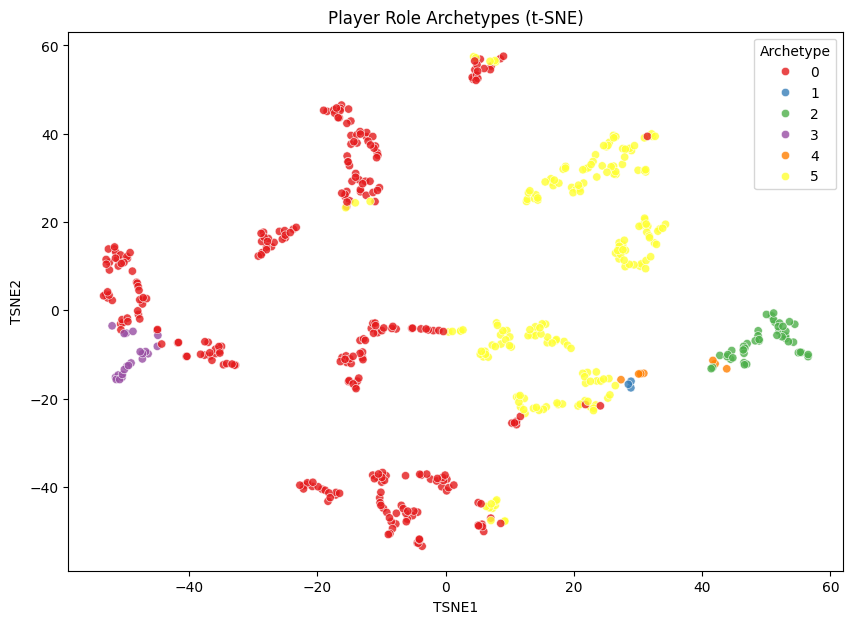

In [48]:
# 15. Visualize Archetypes in Embedding Space
plt.figure(figsize=(10,7))
sns.scatterplot(data=player_roles, x="TSNE1", y="TSNE2",
                hue="role_cluster", palette="Set1", alpha=0.8)
plt.title("Player Role Archetypes (t-SNE)")
plt.legend(title="Archetype")
plt.show()

In [49]:
# 16. List Players by Archetype
for cluster_id, group in player_roles.groupby("role_cluster"):
    print(f"\nRole Archetype {cluster_id}:")
    print(group.index.to_list()[:10])  # show 10 players as sample


Role Archetype 0:
['A. Agbinone', 'A. Armstrong', 'A. Cresswell', 'A. Diallo', 'A. Doucouré', 'A. Elanga', 'A. Garnacho', 'A. Gordon', 'A. Grønbæk', 'A. Irving']

Role Archetype 1:
['S. Mheuka', 'Vitor Reis', 'Youssef Chermiti']

Role Archetype 2:
['A. Aréola', 'A. Bayındır', 'A. Kinský', 'A. McCarthy', 'A. Murić', 'A. Palmer', 'A. Ramsdale', 'Alisson', 'B. Austin', 'B. Leno']

Role Archetype 3:
['B. Gilmour', 'C. Echeverri', 'D. Mubama', 'Daniel Podence', 'E. Buendía', 'F. Onyeka', 'Gustavo Nunes', 'H. Howell', 'H. Reed', 'J. Danns']

Role Archetype 4:
['A. Dorrington', 'E. Cashin', 'J. Sanda', 'M. Amougou', 'M. Mane', 'Pedro Lima', 'Z. Silcott-Duberry']

Role Archetype 5:
['A. Bella-Kotchap', 'A. Broja', 'A. Disasi', 'A. Fatawu', 'A. Gray', 'A. Heaven', 'A. Khusanov', 'A. Onana', 'A. Robertson', 'A. Robinson']


👉 Now we can see which players fall into each role family.

In [50]:
# 17. Combine Archetypes + Similarity

#Finally, you can combine the two ideas:

#First find a player’s archetype (role family).

#Then within that archetype, find the closest players by similarity.

def find_similar_in_role(player_name, top_n=5):
    if player_name not in player_roles.index:
        print(f"⚠️ {player_name} not found")
        return
    
    role_id = player_roles.loc[player_name, "role_cluster"]
    peers = player_roles[player_roles["role_cluster"] == role_id]
    
    sims = sim_df.loc[player_name, peers.index].sort_values(ascending=False).iloc[1:top_n+1]
    return role_id, sims

role_id, peers = find_similar_in_role("Rodri", top_n=5)
print(f"Rodri belongs to Role Archetype {role_id}. Similar players in this archetype:")
print(peers)


Rodri belongs to Role Archetype 0. Similar players in this archetype:
player_name
M. Harness     0.996872
D. Scarlett    0.994411
J. Monga       0.990974
C. Obi         0.984706
Antony         0.983384
Name: Rodri, dtype: float64


# ✅ Wrap-Up for Session 2

By the end of this module, we can:

- Build possessions and extract features.

- Embed possessions → playing styles (direct, tiki-taka, press).

- Aggregate to teams → fingerprints.

- Aggregate to players → embeddings.

- Find similar players (scouting use case).

- Cluster into role archetypes → destroyer, playmaker, winger, striker